# HW13 – Токенизация текста, инференс BERT и базовый fine-tuning для классификации текста


## 1. Импорты, seed и среда

In [1]:
import random
import os
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import load_dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Фиксируем seed для воспроизводимости.
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Определяем устройство.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Seed: {SEED}")

Device: cpu
Seed: 42


## 2. Данные и первичный анализ

Используем датасет **`emotion`** — набор англоязычных коротких текстов , размеченных по 6 эмоциям:

- `sadness` (0)
- `joy` (1)
- `love` (2)
- `anger` (3)
- `fear` (4)
- `surprise` (5)

Задача — классификация текста по эмоции. Датасет уже содержит готовое разбиение на train / validation / test.

In [3]:
# Загружаем датасет emotion.
dataset = load_dataset("dair-ai/emotion")
print("Структура датасета:")
print(dataset)
print()

Структура датасета:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})



In [29]:
# sanity-check
# Названия классов.
label_names = dataset["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print("Классы:", label_names)
print("id2label:", id2label)
print("label2id:", label2id)
print()

# Размеры split-частей.
for split_name in ["train", "validation", "test"]:
    print(f"{split_name}: {len(dataset[split_name])} примеров")

# Общий размер датасета
total_size = sum(len(dataset[split]) for split in dataset.keys())
print(f"\nОбщий размер датасета (все сплиты): {total_size} примеров")


Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Общий размер датасета (все сплиты): 20000 примеров


In [ ]:
# Распределение классов в каждом split.
for split_name in ["train", "validation", "test"]:
    labels = dataset[split_name]["label"]
    counts = pd.Series(labels).map(id2label).value_counts()
    print(f"\n{split_name}:")
    print(counts)

# Общий размер датасета
total_size = sum(len(dataset[split]) for split in dataset.keys())
print(f"\nОбщий размер датасета (все сплиты): {total_size} примеров")



train:
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

validation:
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

test:
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

Общий размер датасета (все сплиты): 20000 примеров


In [6]:
# Примеры текстов и меток (5 примеров из train).
sample_indices = [0, 100, 500, 1000, 3000]
examples = []
for idx in sample_indices:
    item = dataset["train"][idx]
    examples.append({
        "index": idx,
        "text": item["text"],
        "label_id": item["label"],
        "label_name": id2label[item["label"]],
    })

display(pd.DataFrame(examples))


,index,text,label_id,label_name
0,0,i didnt feel humiliated,0,sadness
1,100,i wont let me child cry it out because i feel that loving her and lily when she was little was going to be opportuni...,2,love
2,500,i love children s literature authors who don t feel the need to dumb down things for kids,0,sadness
3,1000,i need to do the best i possibly can do and even when i get out at i feel too listless to study like right now,0,sadness
4,3000,i feel fucking pathetic and desperate for your hello,0,sadness


Классифицируется: короткие англоязычные тексты по эмоции автора.

## 3. Токенизация

Разберём, как текст из датасета превращается во вход для BERT-модели.
Покажем на 5 примерах: токены, `input_ids`, `attention_mask`, special tokens, padding и truncation.

In [7]:
# Загружаем токенизатор для модели, которую будем использовать позже для fine-tuning.
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)
print("Vocab size:", tokenizer.vocab_size)
print("Model max length:", tokenizer.model_max_length)

Tokenizer: BertTokenizer
Model checkpoint: distilbert-base-uncased
Vocab size: 30522
Model max length: 512


In [8]:
# Special tokens.
special_tokens_df = pd.DataFrame({
    "name": ["cls_token", "sep_token", "pad_token", "unk_token", "mask_token"],
    "token": [
        tokenizer.cls_token,
        tokenizer.sep_token,
        tokenizer.pad_token,
        tokenizer.unk_token,
        tokenizer.mask_token,
    ],
    "token_id": [
        tokenizer.cls_token_id,
        tokenizer.sep_token_id,
        tokenizer.pad_token_id,
        tokenizer.unk_token_id,
        tokenizer.mask_token_id,
    ],
})
display(special_tokens_df)

,name,token,token_id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


In [9]:
# Разбор токенизации на 5 примерах из датасета.
tok_examples = [
    dataset["train"][0]["text"],
    dataset["train"][100]["text"],
    dataset["train"][500]["text"],
    dataset["train"][1000]["text"],
    dataset["train"][3000]["text"],
]

for i, text in enumerate(tok_examples):
    print(f" Пример {i + 1} ")
    print(f"Текст: {text}")
    
    tokens = tokenizer.tokenize(text)
    print(f"Токены ({len(tokens)} шт.): {tokens}")
    
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
    )
    full_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    print(f"input_ids (со special tokens): {encoded['input_ids'][:15]}")
    print(f"Токены (со special tokens): {full_tokens[:15]}")
    print(f"attention_mask: {encoded['attention_mask'][:15]}")
    print()

 Пример 1 
Текст: i didnt feel humiliated
Токены (5 шт.): ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids (со special tokens): [101, 1045, 2134, 2102, 2514, 26608, 102]
Токены (со special tokens): ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
attention_mask: [1, 1, 1, 1, 1, 1, 1]

 Пример 2 
Текст: i wont let me child cry it out because i feel that loving her and lily when she was little was going to be opportunities that only lasted for those short few months
Токены (34 шт.): ['i', 'won', '##t', 'let', 'me', 'child', 'cry', 'it', 'out', 'because', 'i', 'feel', 'that', 'loving', 'her', 'and', 'lily', 'when', 'she', 'was', 'little', 'was', 'going', 'to', 'be', 'opportunities', 'that', 'only', 'lasted', 'for', 'those', 'short', 'few', 'months']
input_ids (со special tokens): [101, 1045, 2180, 2102, 2292, 2033, 2775, 5390, 2009, 2041, 2138, 1045, 2514, 2008, 8295]
Токены (со special tokens): ['[CLS]', 'i', 'won', '##t', 'let', 'me', 'child', 'cry', 'it', 'out', 'becaus

In [10]:
# Пример padding и truncation.
short_text = "i feel happy"
long_text = "i am feeling incredibly overwhelmed by everything that has been happening lately and i just cannot seem to find any peace of mind no matter what i try to do about it"

batch_padded = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("Padding + Truncation с max_length=32:")
print(f"input_ids shape: {tuple(batch_padded['input_ids'].shape)}")
print(f"attention_mask shape: {tuple(batch_padded['attention_mask'].shape)}")
print()

for idx, text in enumerate([short_text, long_text]):
    toks = tokenizer.convert_ids_to_tokens(batch_padded["input_ids"][idx].tolist())
    mask = batch_padded["attention_mask"][idx].tolist()
    print(f"Пример {idx}: '{text[:50]}...'")
    print(f"Токены:{toks}")
    print(f"Mask:{mask}")
    print(f"Реальных токенов: {sum(mask)}, padding: {len(mask) - sum(mask)}")
    print()

Padding + Truncation с max_length=32:
input_ids shape: (2, 32)
attention_mask shape: (2, 32)

Пример 0: 'i feel happy...'
Токены:['[CLS]', 'i', 'feel', 'happy', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Mask:[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Реальных токенов: 5, padding: 27

Пример 1: 'i am feeling incredibly overwhelmed by everything ...'
Токены:['[CLS]', 'i', 'am', 'feeling', 'incredibly', 'overwhelmed', 'by', 'everything', 'that', 'has', 'been', 'happening', 'lately', 'and', 'i', 'just', 'cannot', 'seem', 'to', 'find', 'any', 'peace', 'of', 'mind', 'no', 'matter', 'what', 'i', 'try', 'to', 'do', '[SEP]']
Mask:[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Реальных т

## 4. Инференс готовой pretrained модели

Запускаем готовую pretrained модель классификации текста на нескольких примерах из нашего датасета.
Используем модель **`bhadresh-savani/distilbert-base-uncased-emotion`** — уже обученную на emotion-датасете

Затем возьмем модель общего назначения **`distilbert-base-uncased-finetuned-sst-2-english`** (sentiment),
чтобы показать, что модель с другим пространством меток не подходит для нашей конкретной задачи.

In [11]:
# Инференс через pipeline с готовой моделью для emotion.
PRETRAINED_MODEL = "bhadresh-savani/distilbert-base-uncased-emotion"

emotion_pipeline = pipeline(
    task="text-classification",
    model=PRETRAINED_MODEL,
    device=0 if torch.cuda.is_available() else -1,
)

# Берём 5 примеров из test-части для инференса.
inference_texts = [
    dataset["test"][0]["text"],
    dataset["test"][50]["text"],
    dataset["test"][100]["text"],
    dataset["test"][200]["text"],
    dataset["test"][500]["text"],
]
inference_true_labels = [
    id2label[dataset["test"][0]["label"]],
    id2label[dataset["test"][50]["label"]],
    id2label[dataset["test"][100]["label"]],
    id2label[dataset["test"][200]["label"]],
    id2label[dataset["test"][500]["label"]],
]

pipeline_results = emotion_pipeline(inference_texts)

infer_df = pd.DataFrame({
    "text": inference_texts,
    "true_label": inference_true_labels,
    "pred_label": [r["label"] for r in pipeline_results],
    "score": [round(r["score"], 4) for r in pipeline_results],
})

print(f"Инференс готовой модели: {PRETRAINED_MODEL}")
display(infer_df)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7372.11it/s]


Инференс готовой модели: bhadresh-savani/distilbert-base-uncased-emotion


,text,true_label,pred_label,score
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9989
1,i stood up to you i finally stood up to you and now i feel like im being punished if i could go back and do it again,sadness,sadness,0.9983
2,i feel needy but comfortable with it i feel vulnerable but secure i feel the urge to cum hard but i get no relief,sadness,sadness,0.9963
3,i wanted to feel him in my hands and reached out to take him into my waiting eager mouth,joy,joy,0.9914
4,i feel it is dangerous especially for the new believer who is not grounded in the word of god,anger,anger,0.9963


In [12]:
# Ручной low-level инференс для одного текста.
pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
pretrained_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_MODEL).to(device)
pretrained_model.eval()

example_text = inference_texts[0]
encoded = pretrained_tokenizer(example_text, return_tensors="pt", truncation=True, padding=True)
encoded = {k: v.to(device) for k, v in encoded.items()}

with torch.no_grad():
    outputs = pretrained_model(**encoded)

logits = outputs.logits
probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
pred_id = int(np.argmax(probs))

print(f"Текст: {example_text}")
print(f"Logits: {logits.cpu().numpy().round(4)[0]}")
print(f"Probabilities: {probs.round(4)}")
print(f"Predicted: {pretrained_model.config.id2label[pred_id]} (confidence: {probs[pred_id]:.4f})")

# Показываем все вероятности по классам.
prob_df = pd.DataFrame({
    "label": [pretrained_model.config.id2label[i] for i in range(pretrained_model.config.num_labels)],
    "probability": probs.round(4),
}).sort_values("probability", ascending=False, ignore_index=True)
display(prob_df)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9844.01it/s]

Текст: im feeling rather rotten so im not very ambitious right now
Logits: [ 6.8246 -1.5811 -1.5943 -1.3177 -1.8233 -1.711 ]
Probabilities: [9.989e-01 2.000e-04 2.000e-04 3.000e-04 2.000e-04 2.000e-04]
Predicted: sadness (confidence: 0.9989)


,label,probability
0,sadness,0.9989
1,anger,0.0003
2,joy,0.0002
3,love,0.0002
4,fear,0.0002
5,surprise,0.0002


In [13]:
# Пробуем модель с другим пространством меток (sentiment: POSITIVE/NEGATIVE).
# Она не подходит для задачи классификации эмоций.
sentiment_pipe = pipeline(
    task="text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
)

sentiment_results = sentiment_pipe(inference_texts)

mismatch_df = pd.DataFrame({
    "text": inference_texts,
    "true_emotion": inference_true_labels,
    "sentiment_label": [r["label"] for r in sentiment_results],
    "sentiment_score": [round(r["score"], 4) for r in sentiment_results],
})

display(mismatch_df)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6639.39it/s]


,text,true_emotion,sentiment_label,sentiment_score
0,im feeling rather rotten so im not very ambitious right now,sadness,NEGATIVE,0.9998
1,i stood up to you i finally stood up to you and now i feel like im being punished if i could go back and do it again,sadness,NEGATIVE,0.9780
2,i feel needy but comfortable with it i feel vulnerable but secure i feel the urge to cum hard but i get no relief,sadness,NEGATIVE,0.9765
3,i wanted to feel him in my hands and reached out to take him into my waiting eager mouth,joy,POSITIVE,0.9961
4,i feel it is dangerous especially for the new believer who is not grounded in the word of god,anger,NEGATIVE,0.9983


Инференс модели general sentiment POSITIVE/NEGATIVE — не подходит для emotion classification

### Вывод: почему нужна собственная модель?

Готовая модель `sentiment classification` (позитив/негатив) возвращает только классы `POSITIVE` или `NEGATIVE`.
Наша же задача — различает 6 конкретных эмоций (sadness, joy, love, anger, fear, surprise). Пространства меток и логика классификации не совпадают.

**Именно поэтому для решения нашей задачи нужен процесс fine-tuning** — дообучение базовой языковой модели без classification head или предобученной модели, чтобы она предсказывала нужные нам классы.

In [14]:
# Очищаем память от моделей инференса.
del pretrained_model, emotion_pipeline, sentiment_pipe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 5. Fine-tuning для классификации текста

Дообучаем модель **`distilbert-base-uncased`** на датасете `emotion` для классификации по 6 эмоциям.


In [15]:
# Токенизация датасета.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = dataset.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

print("Tokenized datasets:")
print(tokenized_datasets)

Tokenized datasets:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [16]:
# Data collator с динамическим padding.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Проверяем: формируем один батч.
sample_batch = [tokenized_datasets["train"][i] for i in range(4)]
collated = data_collator(sample_batch)
for key, value in collated.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(4,)
input_ids: shape=(4, 23)
token_type_ids: shape=(4, 23)
attention_mask: shape=(4, 23)


In [17]:
# Загружаем модель для sequence classification.
set_seed(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

print("Model:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6628.59it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [18]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
    }

In [19]:
# Параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/hw13_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

print("Настроены обучающие аргументы.")

Настроены обучающие аргументы.


In [20]:
# Собираем Trainer и запускаем fine-tuning.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
print("\nОбучение завершено.")
print(train_result)

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.243316,0.200821,0.927500,0.903896
2,0.134137,0.150417,0.940000,0.915344
3,0.100034,0.147027,0.941000,0.917508


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.69it/s]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Обучение завершено.
TrainOutput(global_step=1500, training_loss=0.28631049950917564, metrics={'train_runtime': 561.1062, 'train_samples_per_second': 85.545, 'train_steps_per_second': 2.673, 'total_flos': 647803507542912.0, 'train_loss': 0.28631049950917564, 'epoch': 3.0})


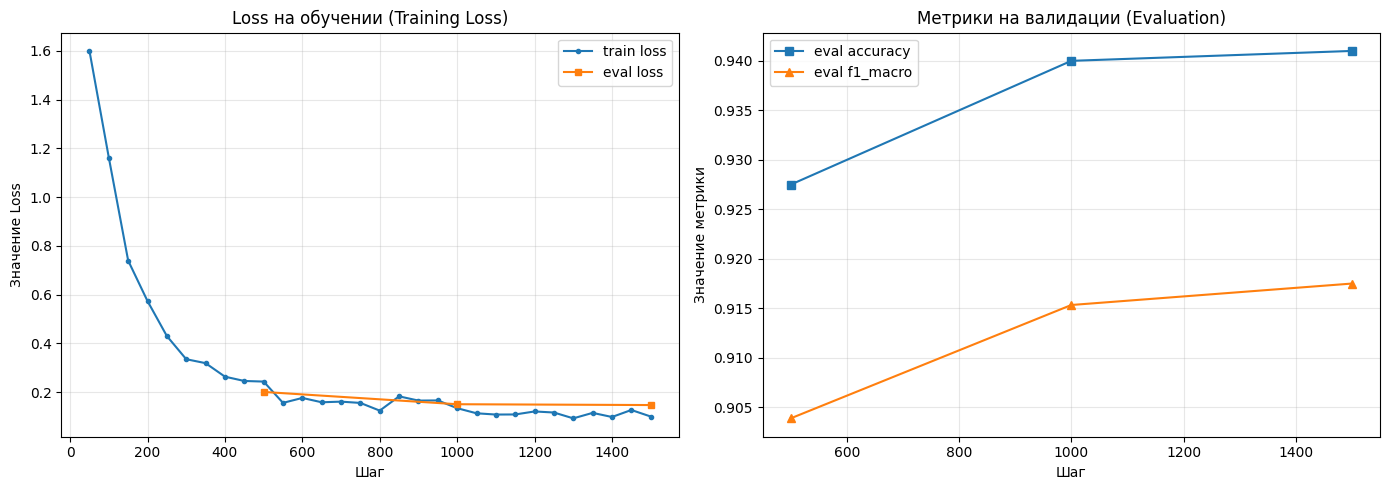

Сохранено: artifacts/training_curves.png


In [21]:
# История обучения.
history_df = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss.
ax = axes[0]
if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    ax.plot(train_logs["step"], train_logs["loss"], marker="o", markersize=3, label="train loss")
if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    ax.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", markersize=5, label="eval loss")
ax.set_title("Loss на обучении (Training Loss)")
ax.set_xlabel("Шаг")
ax.set_ylabel("Значение Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Metrics.
ax = axes[1]
if "eval_accuracy" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_accuracy"])
    ax.plot(eval_logs["step"], eval_logs["eval_accuracy"], marker="s", label="eval accuracy")
if "eval_f1_macro" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_f1_macro"])
    ax.plot(eval_logs["step"], eval_logs["eval_f1_macro"], marker="^", label="eval f1_macro")
ax.set_title("Метрики на валидации (Evaluation)")
ax.set_xlabel("Шаг")
ax.set_ylabel("Значение метрики")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/training_curves.png")

## 6. Оценка качества и краткий анализ ошибок

Оцениваем лучшую модель выбранную по validation f1_macro на test-выборке.
Считаем accuracy, f1_macro, строим матрицу ошибок и разбираем ошибочные предсказания.

In [22]:
# Удаляем NotebookProgressCallback для standalone evaluate().
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

In [23]:
# Оценка на validation.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
  eval_loss: 0.1470
  eval_accuracy: 0.9410
  eval_f1_macro: 0.9175
  eval_runtime: 7.1557
  eval_samples_per_second: 279.4970
  eval_steps_per_second: 4.4720
  epoch: 3.0000


In [ ]:
# Финальная оценка на test.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

test_accuracy = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro")

print("Test metrics:")
print(f"accuracy:{test_accuracy:.4f}")
print(f"f1_macro:{test_f1_macro:.4f}")
print()

print("Classification report test:")
print(classification_report(
    test_true,
    test_preds,
    target_names=label_names,
    zero_division=0,
))

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test metrics:
accuracy:0.9270
f1_macro:0.8863

Classification report (test):
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.95      0.94      0.94       695
        love       0.80      0.83      0.82       159
       anger       0.93      0.92      0.93       275
        fear       0.88      0.95      0.91       224
    surprise       0.85      0.68      0.76        66

    accuracy                           0.93      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.93      0.93      0.93      2000



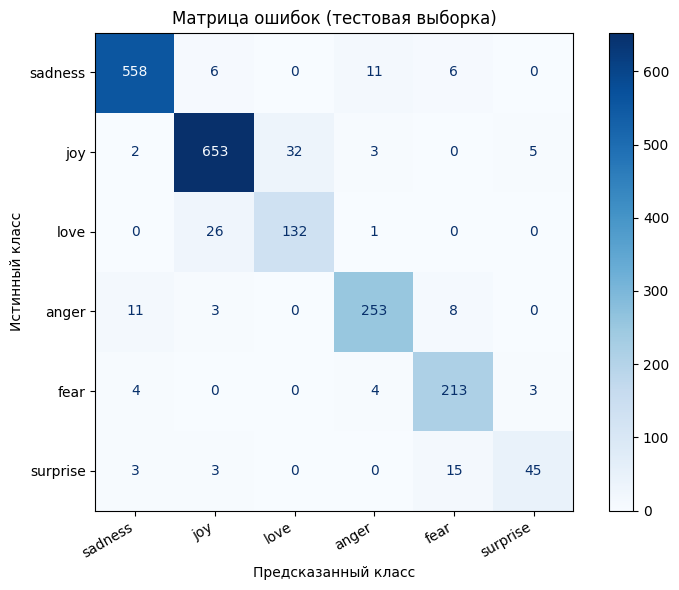

Сохранено: artifacts/confusion_matrix.png


In [25]:
# Матрица ошибок на test-части.
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Матрица ошибок (тестовая выборка)")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

In [ ]:
# Примеры предсказаний модели.
test_texts = dataset["test"]["text"]
test_probs = F.softmax(torch.tensor(test_logits), dim=-1).numpy()

predictions_rows = []
for i in range(len(test_texts)):
    predictions_rows.append({
        "text": test_texts[i],
        "true_label": id2label[int(test_true[i])],
        "pred_label": id2label[int(test_preds[i])],
        "confidence": float(test_probs[i, test_preds[i]]),
    })

predictions_df = pd.DataFrame(predictions_rows)

# Показываем 10 примеров 5 верных + 5 ошибочных
correct = predictions_df[predictions_df["true_label"] == predictions_df["pred_label"]].head(5)
wrong = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].head(5)

print("Примеры верных предсказаний:")
display(correct)

print("\nПримеры ошибочных предсказаний:")
display(wrong)

Примеры верных предсказаний:


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9968
1,im updating my blog because i feel shitty,sadness,sadness,0.9973
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9972
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9973
4,i was feeling a little vain when i did this one,sadness,sadness,0.9973



Примеры ошибочных предсказаний:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.6978
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.6921
72,i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird,surprise,fear,0.6426
86,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,0.6652
94,when a friend dropped a frog down my neck,anger,fear,0.6433


In [27]:
# Сохраняем sample_predictions.csv (все предсказания на test).
predictions_df.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Сохранено: artifacts/sample_predictions.csv ({len(predictions_df)} строк)")
print(predictions_df.head(10))

Сохранено: artifacts/sample_predictions.csv (2000 строк)
                                                                                                                      text true_label pred_label  confidence
0                                                              im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.9968
1                                                                                im updating my blog because i feel shitty    sadness    sadness      0.9973
2                        i never make her separate from me because i don t ever want her to feel like i m ashamed with her    sadness    sadness      0.9972
3        i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived        joy        joy      0.9973
4                                                                          i was feeling a little vain when i did this one    sadness    sadness      0.9973
5

In [28]:
# Анализ ошибок: 10 ошибочных примеров с наибольшей уверенностью модели.
errors_df = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False).head(10).reset_index(drop=True)

print(f"Всего ошибок на test: {len(predictions_df[predictions_df['true_label'] != predictions_df['pred_label']])} из {len(predictions_df)}")
print()

if len(errors_df) > 0:
    print("Ошибки с наибольшей уверенностью модели:")
    display(errors_df)
else:
    print("На тестовой выборке ошибок не обнаружено.")


Всего ошибок на test: 146 из 2000

Ошибки с наибольшей уверенностью модели:


,text,true_label,pred_label,confidence
0,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9961
1,i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible f...,anger,sadness,0.9953
2,i cannot even begin to express in words the depth of sorrow that i feel having not posted any of my ludicrous rants ...,surprise,sadness,0.9935
3,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to ...,fear,sadness,0.9923
4,i walked to school he felt the bounce in his step the overjoyed feelings of youth and the thrill of excitement of co...,love,joy,0.9913
5,i feel unprotected a class post count link href http reprogramming in process,sadness,fear,0.9845
6,when i learnt that my best friend had failed the exams,anger,sadness,0.9841
7,i feel like everything that i hope to become a piller in my life i cling to i despise myself for clinging to somethi...,sadness,anger,0.9688
8,i just feel are ludicrous and wasting space or so trite they should have looked at the book first and come up with s...,surprise,sadness,0.9665
9,i felt confused me sometimes that makes me feel useless,sadness,fear,0.9565


### Краткий анализ ошибок

1. Многие ошибки связаны с путаницей между близкими эмоциями: **joy/love**, **sadness/fear**, **anger/sadness**.
2. Некоторые тексты содержат смешанные эмоциональные сигналы, что затрудняет однозначную классификацию.
3. Короткие тексты с неоднозначным контекстом — наиболее трудные для модели.
4. Высокая уверенность модели при ошибке (уверенное заблуждение) обычно возникает, когда лексика текста сильно коррелирует с другим классом.

## 7. Итоги

1. **Датасет:** `emotion` — 6 классов эмоций, готовое разбиение train/validation/test.
2. **Токенизация:** разобрали на примерах, как текст превращается во входы модели (input_ids, attention_mask, special tokens, padding, truncation).
3. **Инференс готовой модели:** показали, что специализированная pretrained модель хорошо справляется, а модель с другим пространством меток — нет.
4. **Fine-tuning:** дообучили `distilbert-base-uncased` на 3 эпохе, выбрали лучшую модель по validation f1_macro.
5. **Результат на test:** accuracy и f1_macro посчитаны, матрица ошибок построена.
6. **Обязательные артефакты:** `sample_predictions.csv`, `confusion_matrix.png` — в `artifacts/`.